# Prototip: simulacija rada u stvarnom vremenu

Ova bilježnica predstavlja samostalni prototip sustava za detekciju anomalija, opisan u poglavlju 4.7. završnog rada. Učitava već istrenirani autoenkoder, odabran kao konačni model u poglavlju 4.6., te ga primjenjuje na testni skup kako bi se demonstrirao rad sustava u okruženju sličnom stvarnom vremenu.

In [2]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
!pip install -q tensorflow

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow import keras

RANDOM_STATE = 42

## 1. Priprema testnog skupa

Ponavlja se identičan postupak podjele i skaliranja kao u autoencoder.ipynb (kronološka podjela 70:30, RobustScaler prilagođen isključivo na trening skupu), kako bi se dobio testni skup brojčano identičan onom korištenom pri treniranju i evaluaciji modela. Skup za treniranje
i validaciju ovdje nije potreban jer se model ne trenira iznova.

In [3]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")

split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

amount_scaler = RobustScaler()
amount_scaler.fit(train_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
time_scaler.fit(train_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

X_test = test_df[feature_cols].values
y_test = test_df['Class'].values

print(f"Test: {X_test.shape}, Fraud rate: {y_test.mean() * 100:.4f} %")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Test: (85443, 30), Fraud rate: 0.1264 %


## 2. Učitavanje istreniranog modela

Pokreni sljedeću ćeliju i učitaj autoencoder_model.keras.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving autoencoder_model.keras to autoencoder_model.keras


In [5]:
autoencoder = keras.models.load_model('autoencoder_model.keras')
print("Model loaded successfully.")

Model loaded successfully.


## 3. Izračun pogreške rekonstrukcije

Prag odlučivanja (θ = 1,3905) već je usvojena vrijednost,
ne računa se ponovno u ovoj bilježnici.

In [6]:
THRESHOLD = 1.3905

X_test_pred = autoencoder.predict(X_test, verbose=0)
reconstruction_error = np.mean(np.square(X_test - X_test_pred), axis=1)

flagged = reconstruction_error > THRESHOLD
actual_fraud = (y_test == 1)

print(f"Total number of transactions: {len(y_test)}")
print(f"Flagged as suspicious: {flagged.sum()}")
print(f"Correctly identified frauds: {(flagged & actual_fraud).sum()}")

Total number of transactions: 85443
Flagged as suspicious: 860
Correctly identified frauds: 76


## 4. Simulacija rada u stvarnom vremenu

### 4.1. Prikaz za rad

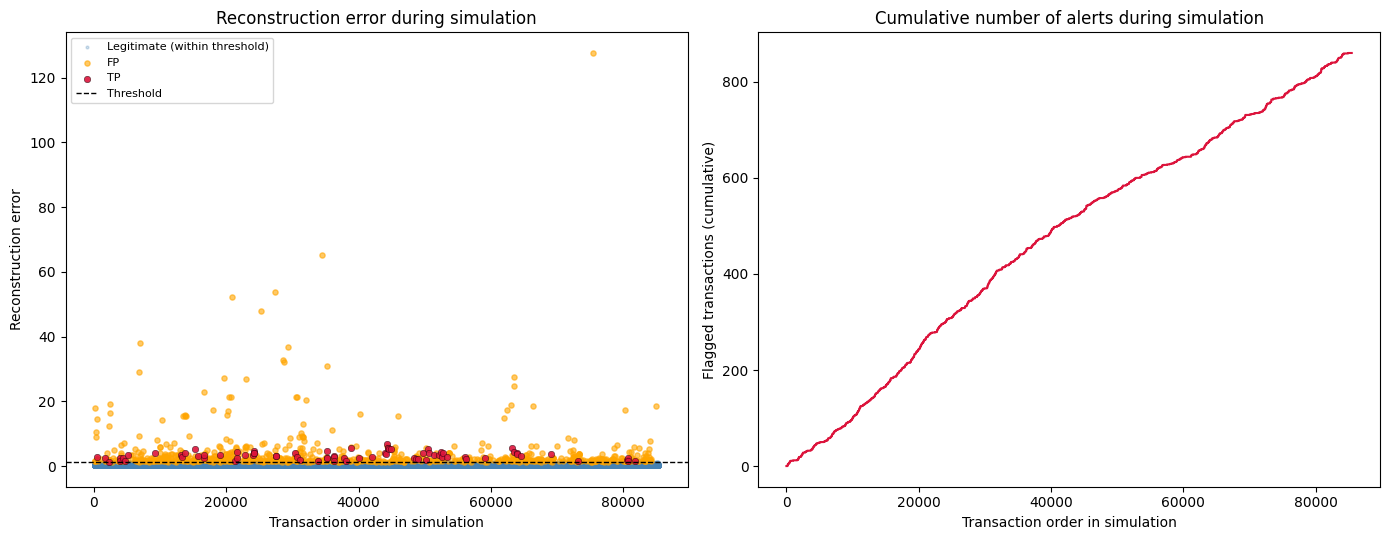

Total transactions processed: 85443
Total flagged as suspicious: 860
Correctly identified frauds: 76
FP: 784
FN: 32


In [7]:
indices = np.arange(len(reconstruction_error))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(indices[~flagged], reconstruction_error[~flagged],
                s=4, alpha=0.25, color='steelblue', label='Legitimate (within threshold)')
axes[0].scatter(indices[flagged & ~actual_fraud], reconstruction_error[flagged & ~actual_fraud],
                s=14, alpha=0.6, color='orange', label='FP')
axes[0].scatter(indices[flagged & actual_fraud], reconstruction_error[flagged & actual_fraud],
                s=22, alpha=0.9, color='crimson', edgecolors='k', linewidths=0.3,
                label='TP')
axes[0].axhline(THRESHOLD, color='black', linestyle='--', linewidth=1, label='Threshold')
axes[0].set_xlabel('Transaction order in simulation')
axes[0].set_ylabel('Reconstruction error')
axes[0].set_title('Reconstruction error during simulation')
axes[0].legend(fontsize=8)

cumulative_flagged = np.cumsum(flagged)
axes[1].plot(indices, cumulative_flagged, color='crimson')
axes[1].set_xlabel('Transaction order in simulation')
axes[1].set_ylabel('Flagged transactions (cumulative)')
axes[1].set_title('Cumulative number of alerts during simulation')

plt.tight_layout()
plt.show()

print(f"Total transactions processed: {len(y_test)}")
print(f"Total flagged as suspicious: {flagged.sum()}")
print(f"Correctly identified frauds: {(flagged & actual_fraud).sum()}")
print(f"FP: {(flagged & ~actual_fraud).sum()}")
print(f"FN: {(~flagged & actual_fraud).sum()}")

### 4.2. Live demonstracija

Postupno iscrtavanje kroz podskup testnih transakcija, s malim umjetnim odmakom između serija radi vizualnog efekta "pristizanja" transakcija.

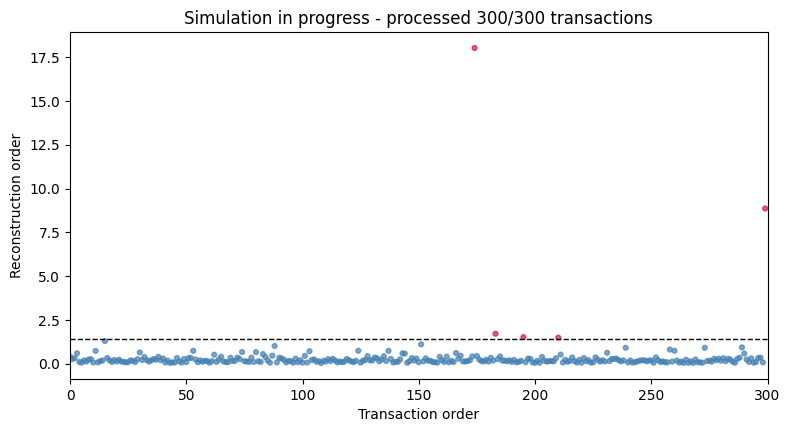

Flagged as suspicious: 5 | Correctly identified frauds: 0
Simulation done.


In [9]:
import time
from IPython.display import clear_output

N_DEMO = 300
BATCH_SIZE = 5
DELAY = 0.3

demo_errors = reconstruction_error[:N_DEMO]
demo_actual = actual_fraud[:N_DEMO]
demo_flagged = demo_errors > THRESHOLD

running_flagged = 0
running_caught = 0

for start in range(0, N_DEMO, BATCH_SIZE):
    end = min(start + BATCH_SIZE, N_DEMO)
    running_flagged += demo_flagged[start:end].sum()
    running_caught += (demo_flagged[start:end] & demo_actual[start:end]).sum()

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.scatter(np.arange(end), demo_errors[:end],
               c=np.where(demo_flagged[:end], 'crimson', 'steelblue'), s=12, alpha=0.7)
    ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(0, N_DEMO)
    ax.set_xlabel('Transaction order')
    ax.set_ylabel('Reconstruction order')
    ax.set_title(f'Simulation in progress - processed {end}/{N_DEMO} transactions')
    plt.show()

    print(f"Flagged as suspicious: {running_flagged} | Correctly identified frauds: {running_caught}")
    time.sleep(DELAY)

print("Simulation done.")